# PA-100K Pedestrian Attribute Recognition
## Exploratory Data Analysis & Attribute Selection

This notebook performs a systematic exploratory analysis of the **PA-100K Pedestrian Attribute Recognition dataset** before model development.

### Objectives

1. Understand the structure of PA-100K.
2. Validate the official train, validation, and test splits.
3. Analyse the distribution of all 26 pedestrian attributes.
4. Quantify class imbalance.
5. Identify common, medium-frequency, rare, and extremely rare attributes.
6. Investigate distribution shifts between train/validation/test sets.
7. Analyse relationships between pedestrian attributes.
8. Identify mutually exclusive attribute groups.
9. Select a practical subset of attributes for lightweight PAR experiments.
10. Establish the motivation for imbalance-aware training.

---

### Dataset

**PA-100K**

- Total pedestrian images: **100,000**
- Training: **80,000**
- Validation: **10,000**
- Testing: **10,000**
- Number of attributes: **26**

The analysis in this notebook will guide the subsequent model design rather than selecting attributes arbitrarily.

In [3]:
%pip install numpy pandas matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.2 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 3.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 3.8 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


## Paths

In [7]:
# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

TRAIN_PATH = DATA_DIR / "train.csv"
VAL_PATH   = DATA_DIR / "val.csv"
TEST_PATH  = DATA_DIR / "test.csv"

ANNOTATION_PATH = DATA_DIR / "annotation.mat"


for path in [TRAIN_PATH, VAL_PATH, TEST_PATH, ANNOTATION_PATH]:
    print(f"{path.name:20s}: {'FOUND' if path.exists() else 'NOT FOUND'}")

train.csv           : FOUND
val.csv             : FOUND
test.csv            : FOUND
annotation.mat      : FOUND


## Load the dataset

In [8]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Dataset loaded successfully.\n")

print(f"Train shape      : {train_df.shape}")
print(f"Validation shape : {val_df.shape}")
print(f"Test shape       : {test_df.shape}")
print(f"Total samples    : {len(train_df) + len(val_df) + len(test_df):,}")

Dataset loaded successfully.

Train shape      : (80000, 27)
Validation shape : (10000, 27)
Test shape       : (10000, 27)
Total samples    : 100,000


## Dataset preview

In [9]:
display(train_df.head())

,Image,Female,AgeOver60,Age18-60,AgeLess18,Front,Side,Back,Hat,Glasses,HandBag,ShoulderBag,Backpack,HoldObjectsInFront,ShortSleeve,LongSleeve,UpperStride,UpperLogo,UpperPlaid,UpperSplice,LowerStripe,LowerPattern,LongCoat,Trousers,Shorts,Skirt&Dress,boots
0,000001.jpg,1,0,1,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0
1,000002.jpg,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,000003.jpg,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0
3,000004.jpg,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,000005.jpg,1,0,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0


In [10]:
print("Columns:")
for i, column in enumerate(train_df.columns):
    print(f"{i:2d}  {column}")

Columns:
 0  Image
 1  Female
 2  AgeOver60
 3  Age18-60
 4  AgeLess18
 5  Front
 6  Side
 7  Back
 8  Hat
 9  Glasses
10  HandBag
11  ShoulderBag
12  Backpack
13  HoldObjectsInFront
14  ShortSleeve
15  LongSleeve
16  UpperStride
17  UpperLogo
18  UpperPlaid
19  UpperSplice
20  LowerStripe
21  LowerPattern
22  LongCoat
23  Trousers
24  Shorts
25  Skirt&Dress
26  boots


### Initial Observation

Each row represents one pedestrian image.

The `Image` column identifies the corresponding image, while the remaining columns represent pedestrian attributes encoded as binary labels.

Unlike conventional single-class classification, PA-100K is primarily a **multi-label classification problem**, because one pedestrian can simultaneously possess multiple attributes.

For example, a pedestrian may simultaneously be:

- Female
- Front-facing
- Wearing glasses
- Carrying a backpack
- Wearing long sleeves
- Wearing trousers

However, some subsets of attributes represent mutually exclusive categorical concepts such as orientation and sleeve length. These relationships will be investigated later.

## Dataset integrity

In [11]:
splits = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}

attribute_cols = [c for c in train_df.columns if c != "Image"]

integrity_rows = []

for name, df in splits.items():

    label_values = df[attribute_cols].to_numpy()

    integrity_rows.append({
        "Split": name,
        "Samples": len(df),
        "Columns": len(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Image Names": int(df["Image"].duplicated().sum()),
        "Invalid Label Values": int(
            np.sum(~np.isin(label_values, [0, 1]))
        )
    })

integrity_df = pd.DataFrame(integrity_rows)

display(integrity_df)

,Split,Samples,Columns,Missing Values,Duplicate Image Names,Invalid Label Values
0,Train,80000,27,0,0,0
1,Validation,10000,27,0,0,0
2,Test,10000,27,0,0,0


## Verify columns

In [12]:
assert list(train_df.columns) == list(val_df.columns), \
    "Train and validation columns differ."

assert list(train_df.columns) == list(test_df.columns), \
    "Train and test columns differ."

print("✓ All three splits use identical columns.")
print(f"✓ Number of pedestrian attributes: {len(attribute_cols)}")

✓ All three splits use identical columns.
✓ Number of pedestrian attributes: 26


## Split overview

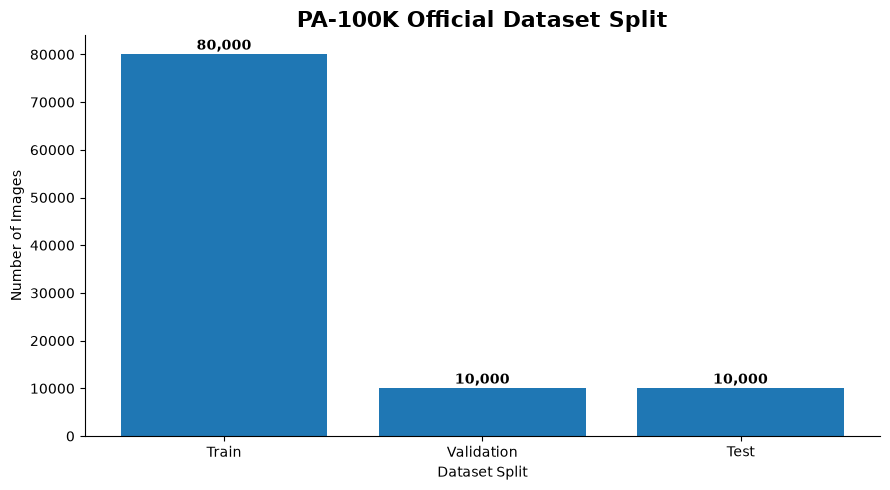

In [13]:
split_sizes = pd.Series({
    "Train": len(train_df),
    "Validation": len(val_df),
    "Test": len(test_df)
})

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(split_sizes.index, split_sizes.values)

ax.set_title(
    "PA-100K Official Dataset Split",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("Number of Images")
ax.set_xlabel("Dataset Split")

for bar, value in zip(bars, split_sizes.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 1000,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Attribute statistics function

In [14]:
def calculate_attribute_statistics(df, attributes):
    records = []

    n = len(df)

    for attr in attributes:

        positive = int(df[attr].sum())
        negative = n - positive

        positive_pct = (positive / n) * 100
        negative_pct = (negative / n) * 100

        minority = min(positive, negative)
        majority = max(positive, negative)

        imbalance_ratio = (
            majority / minority
            if minority > 0
            else np.inf
        )

        records.append({
            "Attribute": attr,
            "Positive": positive,
            "Negative": negative,
            "Positive %": positive_pct,
            "Negative %": negative_pct,
            "Imbalance Ratio": imbalance_ratio
        })

    return pd.DataFrame(records)

## Full-dataset statistics

In [17]:
%pip install jinja2

full_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

overall_stats = calculate_attribute_statistics(
    full_df,
    attribute_cols
)

overall_stats = overall_stats.sort_values(
    "Positive %",
    ascending=False
).reset_index(drop=True)

display(
    overall_stats.style
    .format({
        "Positive": "{:,}",
        "Negative": "{:,}",
        "Positive %": "{:.2f}%",
        "Negative %": "{:.2f}%",
        "Imbalance Ratio": "{:.2f}"
    })
)

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

[notice] A new release of pip is available: 23.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Attribute,Positive,Negative,Positive %,Negative %,Imbalance Ratio
0,Age18-60,"92,844","7,156",92.84%,7.16%,12.97
1,Trousers,"71,916","28,084",71.92%,28.08%,2.56
2,ShortSleeve,"56,913","43,087",56.91%,43.09%,1.32
3,Female,"45,336","54,664",45.34%,54.66%,1.21
4,LongSleeve,"43,087","56,913",43.09%,56.91%,1.32
5,Back,"34,785","65,215",34.78%,65.22%,1.87
6,Front,"34,707","65,293",34.71%,65.29%,1.88
7,Side,"30,508","69,492",30.51%,69.49%,2.28
8,ShoulderBag,"19,301","80,699",19.30%,80.70%,4.18
9,Glasses,"18,662","81,338",18.66%,81.34%,4.36


## Positive prevalence of all 26 attributes

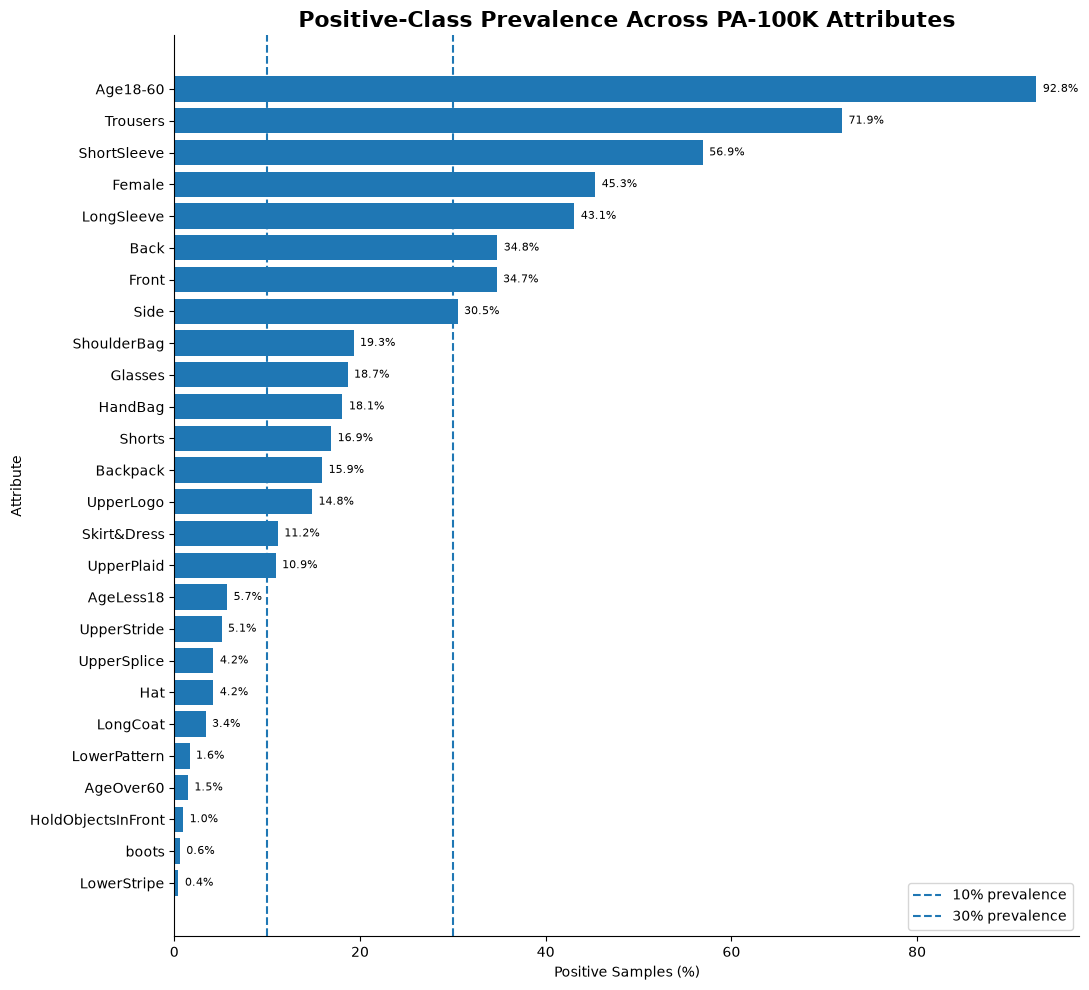

In [18]:
plot_df = overall_stats.sort_values(
    "Positive %",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(
    plot_df["Attribute"],
    plot_df["Positive %"]
)

ax.axvline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="10% prevalence"
)

ax.axvline(
    30,
    linestyle="--",
    linewidth=1.5,
    label="30% prevalence"
)

ax.set_title(
    "Positive-Class Prevalence Across PA-100K Attributes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Positive Samples (%)")
ax.set_ylabel("Attribute")

for bar, value in zip(bars, plot_df["Positive %"]):
    ax.text(
        value + 0.7,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontsize=8
    )

ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Key Observation — Severe Attribute Imbalance

PA-100K exhibits substantial variation in attribute prevalence.

Some attributes occur frequently, while others are present in fewer than 1–5% of pedestrian images.

This creates an important modelling challenge.

For a highly imbalanced attribute, a classifier can achieve deceptively high conventional accuracy simply by predicting the majority class.

For example, if an attribute occurs in only 1% of samples, predicting the attribute as absent for every image would produce approximately 99% accuracy while providing no useful recognition capability.

Therefore, **overall accuracy alone is not an appropriate evaluation metric for this project**.

Later experiments will additionally consider:

- Mean Accuracy (mA)
- Precision
- Recall
- Macro F1
- Micro F1
- Per-attribute F1
- PR-AUC
- Minority/rare-attribute performance

## Create frequency groups

In [19]:
def prevalence_group(p):
    if p < 2:
        return "Extreme Rare"
    elif p < 10:
        return "Rare"
    elif p < 30:
        return "Medium"
    else:
        return "Common"

overall_stats["Frequency Group"] = (
    overall_stats["Positive %"]
    .apply(prevalence_group)
)

display(
    overall_stats[
        [
            "Attribute",
            "Positive",
            "Positive %",
            "Imbalance Ratio",
            "Frequency Group"
        ]
    ].sort_values("Positive %")
    .style
    .format({
        "Positive": "{:,}",
        "Positive %": "{:.2f}%",
        "Imbalance Ratio": "{:.2f}"
    })
)

,Attribute,Positive,Positive %,Imbalance Ratio,Frequency Group
25,LowerStripe,450,0.45%,221.22,Extreme Rare
24,boots,595,0.60%,167.07,Extreme Rare
23,HoldObjectsInFront,958,0.96%,103.38,Extreme Rare
22,AgeOver60,"1,469",1.47%,67.07,Extreme Rare
21,LowerPattern,"1,639",1.64%,60.01,Extreme Rare
20,LongCoat,"3,365",3.36%,28.72,Rare
19,Hat,"4,206",4.21%,22.78,Rare
18,UpperSplice,"4,219",4.22%,22.70,Rare
17,UpperStride,"5,088",5.09%,18.65,Rare
16,AgeLess18,"5,687",5.69%,16.58,Rare


## How many attributes belong to each group?

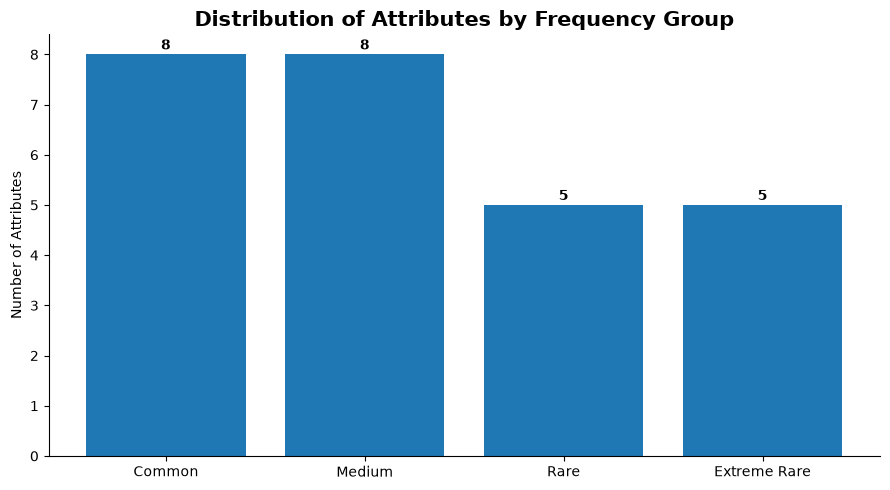

In [20]:
group_order = [
    "Common",
    "Medium",
    "Rare",
    "Extreme Rare"
]

group_counts = (
    overall_stats["Frequency Group"]
    .value_counts()
    .reindex(group_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(group_counts.index, group_counts.values)

ax.set_title(
    "Distribution of Attributes by Frequency Group",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Number of Attributes")

for bar, value in zip(bars, group_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        str(value),
        ha="center",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Imbalance ratio

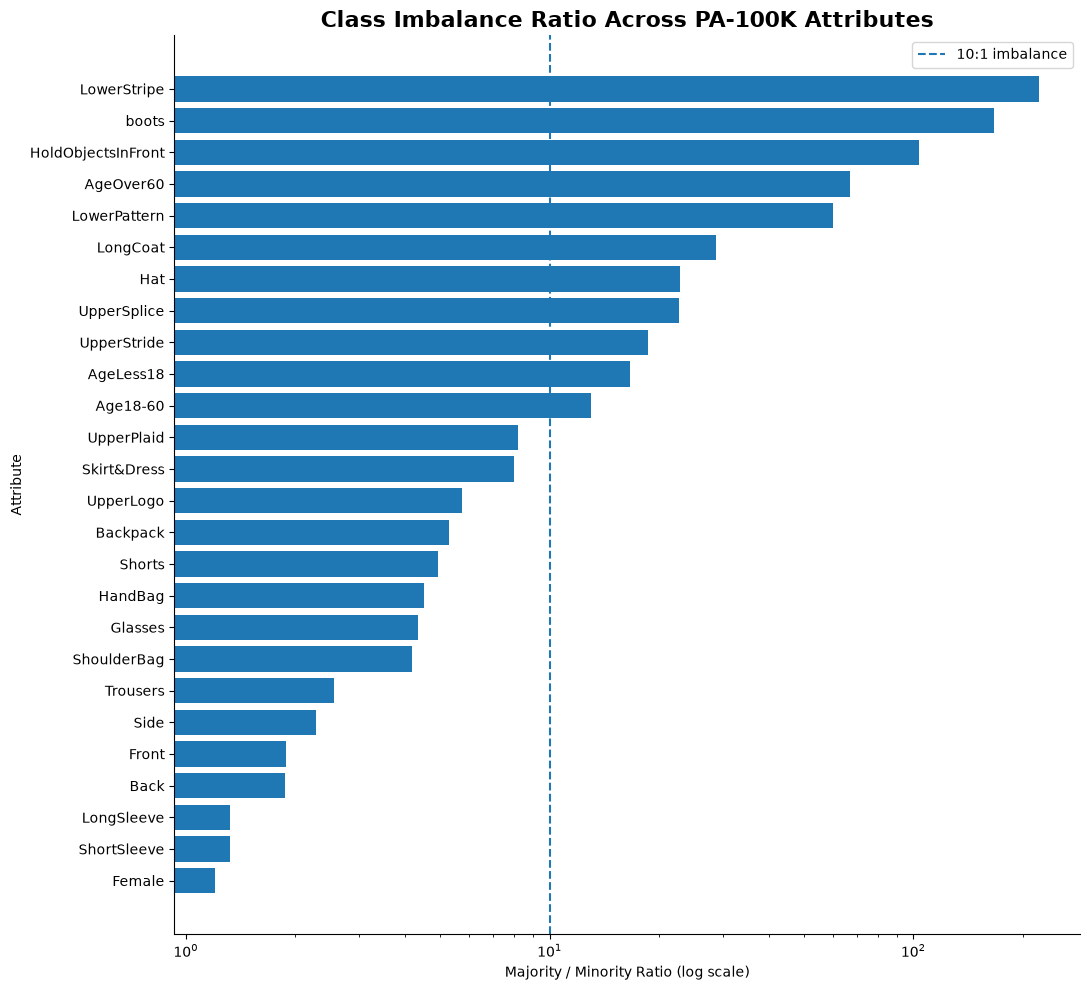

In [21]:
imbalance_plot = overall_stats.sort_values(
    "Imbalance Ratio",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 10))

ax.barh(
    imbalance_plot["Attribute"],
    imbalance_plot["Imbalance Ratio"]
)

ax.set_xscale("log")

ax.set_title(
    "Class Imbalance Ratio Across PA-100K Attributes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Majority / Minority Ratio (log scale)"
)

ax.set_ylabel("Attribute")

ax.axvline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="10:1 imbalance"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Extreme labels

In [22]:
extreme_attributes = (
    overall_stats[
        overall_stats["Frequency Group"] == "Extreme Rare"
    ]
    .sort_values("Positive %")
)

display(
    extreme_attributes[
        [
            "Attribute",
            "Positive",
            "Negative",
            "Positive %",
            "Imbalance Ratio"
        ]
    ].style.format({
        "Positive": "{:,}",
        "Negative": "{:,}",
        "Positive %": "{:.2f}%",
        "Imbalance Ratio": "{:.1f}:1"
    })
)

,Attribute,Positive,Negative,Positive %,Imbalance Ratio
25,LowerStripe,450,"99,550",0.45%,221.2:1
24,boots,595,"99,405",0.60%,167.1:1
23,HoldObjectsInFront,958,"99,042",0.96%,103.4:1
22,AgeOver60,"1,469","98,531",1.47%,67.1:1
21,LowerPattern,"1,639","98,361",1.64%,60.0:1


### Interpretation

Extremely rare attributes require special attention.

When only a few hundred positive samples are available, aggressive dataset reduction or naive random subsampling may leave too few minority examples for meaningful learning.

For this reason, extremely rare attributes will **not automatically be included in the initial lightweight model**.

However, moderately rare attributes will deliberately be retained so that the effectiveness of imbalance-aware loss functions can still be evaluated.

## Train / Validation / Test comparison

In [23]:
split_prevalence = pd.DataFrame({
    "Attribute": attribute_cols,
    "Train": [
        train_df[a].mean() * 100
        for a in attribute_cols
    ],
    "Validation": [
        val_df[a].mean() * 100
        for a in attribute_cols
    ],
    "Test": [
        test_df[a].mean() * 100
        for a in attribute_cols
    ]
})

split_prevalence["Max Shift"] = (
    split_prevalence[
        ["Train", "Validation", "Test"]
    ].max(axis=1)
    -
    split_prevalence[
        ["Train", "Validation", "Test"]
    ].min(axis=1)
)

display(
    split_prevalence
    .sort_values("Max Shift", ascending=False)
    .style.format({
        "Train": "{:.2f}%",
        "Validation": "{:.2f}%",
        "Test": "{:.2f}%",
        "Max Shift": "{:.2f} pp"
    })
)

,Attribute,Train,Validation,Test,Max Shift
13,ShortSleeve,58.60%,56.28%,44.07%,14.53 pp
14,LongSleeve,41.40%,43.72%,55.93%,14.53 pp
3,AgeLess18,5.19%,14.43%,0.92%,13.51 pp
2,Age18-60,93.40%,84.73%,96.50%,11.77 pp
5,Side,28.38%,38.10%,39.92%,11.54 pp
11,Backpack,14.76%,26.02%,15.17%,11.26 pp
0,Female,45.62%,49.48%,38.96%,10.52 pp
22,Trousers,70.90%,73.35%,78.62%,7.72 pp
8,Glasses,17.91%,18.67%,24.64%,6.73 pp
4,Front,35.90%,30.22%,29.67%,6.23 pp


## Distribution-shift plot

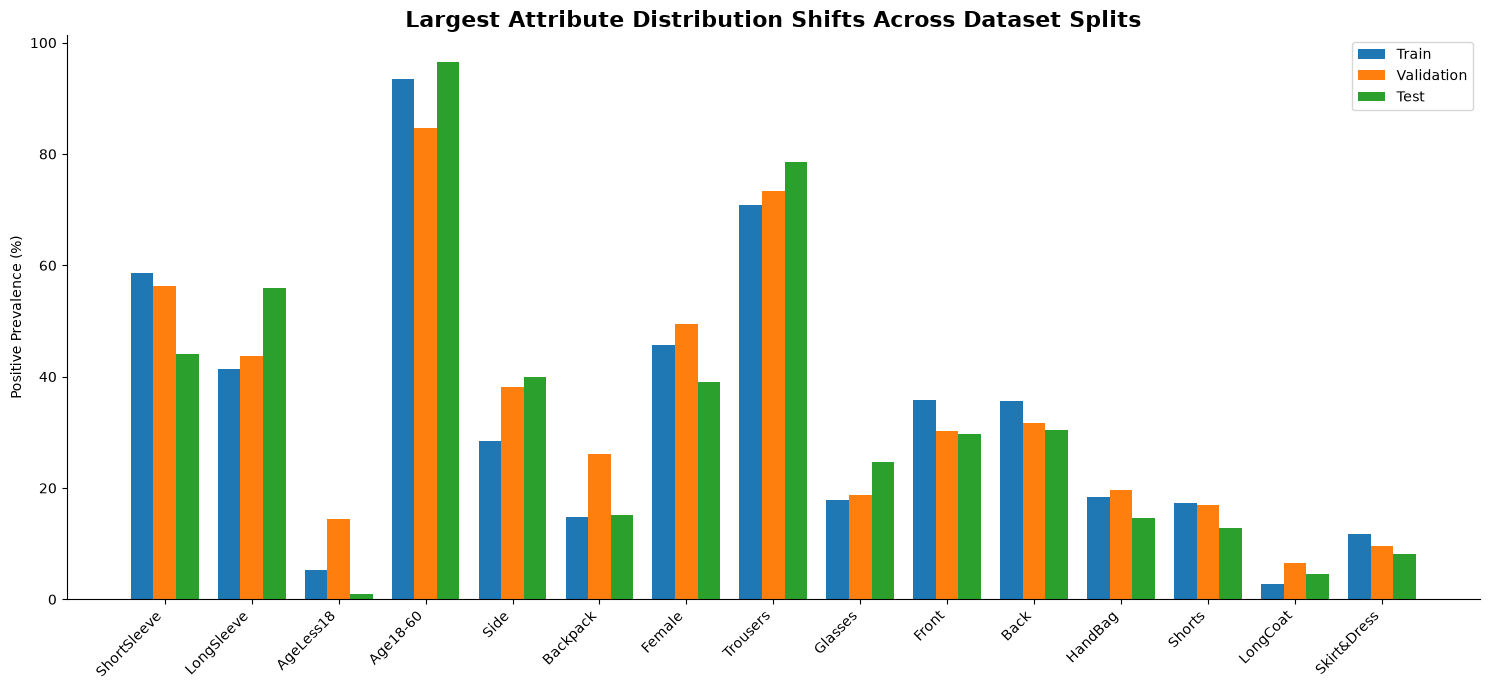

In [24]:
shift_plot = split_prevalence.sort_values(
    "Max Shift",
    ascending=False
).head(15)

x = np.arange(len(shift_plot))
width = 0.26

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(
    x - width,
    shift_plot["Train"],
    width,
    label="Train"
)

ax.bar(
    x,
    shift_plot["Validation"],
    width,
    label="Validation"
)

ax.bar(
    x + width,
    shift_plot["Test"],
    width,
    label="Test"
)

ax.set_xticks(x)
ax.set_xticklabels(
    shift_plot["Attribute"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("Positive Prevalence (%)")

ax.set_title(
    "Largest Attribute Distribution Shifts Across Dataset Splits",
    fontsize=16,
    fontweight="bold"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Identify problematic split shifts

In [25]:
SHIFT_THRESHOLD = 5.0  # percentage points

shifted_attributes = split_prevalence[
    split_prevalence["Max Shift"] >= SHIFT_THRESHOLD
].sort_values(
    "Max Shift",
    ascending=False
)

print(
    f"Attributes with >= {SHIFT_THRESHOLD:.0f} percentage-point "
    f"distribution shift: {len(shifted_attributes)}"
)

display(
    shifted_attributes.style.format({
        "Train": "{:.2f}%",
        "Validation": "{:.2f}%",
        "Test": "{:.2f}%",
        "Max Shift": "{:.2f} pp"
    })
)

Attributes with >= 5 percentage-point distribution shift: 12


,Attribute,Train,Validation,Test,Max Shift
13,ShortSleeve,58.60%,56.28%,44.07%,14.53 pp
14,LongSleeve,41.40%,43.72%,55.93%,14.53 pp
3,AgeLess18,5.19%,14.43%,0.92%,13.51 pp
2,Age18-60,93.40%,84.73%,96.50%,11.77 pp
5,Side,28.38%,38.10%,39.92%,11.54 pp
11,Backpack,14.76%,26.02%,15.17%,11.26 pp
0,Female,45.62%,49.48%,38.96%,10.52 pp
22,Trousers,70.90%,73.35%,78.62%,7.72 pp
8,Glasses,17.91%,18.67%,24.64%,6.73 pp
4,Front,35.90%,30.22%,29.67%,6.23 pp


## Attribute-group consistency

In [26]:
attribute_groups = {
    "Age": [
        "AgeOver60",
        "Age18-60",
        "AgeLess18"
    ],
    "Orientation": [
        "Front",
        "Side",
        "Back"
    ],
    "Sleeve": [
        "ShortSleeve",
        "LongSleeve"
    ],
    "Lower Clothing": [
        "Trousers",
        "Shorts",
        "Skirt&Dress"
    ]
}

group_results = []

for split_name, df in splits.items():

    for group_name, cols in attribute_groups.items():

        count_per_image = df[cols].sum(axis=1)

        group_results.append({
            "Split": split_name,
            "Group": group_name,
            "Exactly One": int((count_per_image == 1).sum()),
            "None": int((count_per_image == 0).sum()),
            "Multiple": int((count_per_image > 1).sum()),
            "Exactly One %": (
                (count_per_image == 1).mean() * 100
            )
        })

group_consistency = pd.DataFrame(group_results)

display(
    group_consistency.style.format({
        "Exactly One": "{:,}",
        "None": "{:,}",
        "Multiple": "{:,}",
        "Exactly One %": "{:.3f}%"
    })
)

,Split,Group,Exactly One,None,Multiple,Exactly One %
0,Train,Age,"80,000",0,0,100.000%
1,Train,Orientation,"80,000",0,0,100.000%
2,Train,Sleeve,"80,000",0,0,100.000%
3,Train,Lower Clothing,"80,000",0,0,100.000%
4,Validation,Age,"10,000",0,0,100.000%
5,Validation,Orientation,"10,000",0,0,100.000%
6,Validation,Sleeve,"10,000",0,0,100.000%
7,Validation,Lower Clothing,"10,000",0,0,100.000%
8,Test,Age,"10,000",0,0,100.000%
9,Test,Orientation,"10,000",0,0,100.000%


## Architectural Implication

The EDA reveals that not all PA-100K labels should necessarily be treated as completely independent binary attributes.

Several groups behave as categorical variables:

### Orientation
- Front
- Side
- Back

### Sleeve Type
- ShortSleeve
- LongSleeve

### Age
- AgeLess18
- Age18-60
- AgeOver60

### Lower Clothing
- Trousers
- Shorts
- Skirt&Dress

This motivates investigating a **multi-task architecture** in which a shared visual backbone feeds multiple prediction heads.

For example:

- Binary sigmoid head → Female
- Softmax head → Orientation
- Softmax head → Sleeve type
- Softmax head → Lower clothing
- Multi-label sigmoid head → Accessories

This structure better reflects the semantics of the annotations than treating every label as an unrelated binary prediction.

## Attribute co-occurrence

In [27]:
cooccurrence = (
    full_df[attribute_cols].T
    @ full_df[attribute_cols]
)

cooccurrence = cooccurrence.astype(int)

display(cooccurrence)

,Female,AgeOver60,Age18-60,AgeLess18,Front,Side,Back,Hat,Glasses,HandBag,ShoulderBag,Backpack,HoldObjectsInFront,ShortSleeve,LongSleeve,UpperStride,UpperLogo,UpperPlaid,UpperSplice,LowerStripe,LowerPattern,LongCoat,Trousers,Shorts,Skirt&Dress,boots
Female,45336,515,42221,2600,15612,13118,16606,430,4349,10719,14081,6793,459,27552,17784,1776,6728,3923,1340,350,1203,2996,26739,7438,11129,424
AgeOver60,515,1469,0,0,642,430,397,9,41,333,75,3,4,794,675,5,215,32,63,0,12,8,1439,14,16,45
Age18-60,42221,0,92844,0,31220,28316,33308,4171,17881,17643,19181,11814,948,50912,41932,5025,14229,10343,4123,399,1510,3352,69139,12843,10829,546
AgeLess18,2600,0,0,5687,2845,1762,1080,26,740,139,45,4109,6,5207,480,58,391,542,33,51,117,5,1338,4039,310,4
Front,15612,642,31220,2845,34707,0,0,1294,8853,6598,6531,5203,344,20637,14070,1598,7629,3499,1027,196,615,1045,24856,6266,3581,273
Side,13118,430,28316,1762,0,30508,0,987,7640,5449,5218,4910,409,17437,13071,1575,4678,2957,1325,120,505,857,22420,4801,3269,116
Back,16606,397,33308,1080,0,0,34785,1925,2169,6068,7552,5813,205,18839,15946,1915,2528,4461,1867,134,519,1463,24640,5829,4305,206
Hat,430,9,4171,26,1294,987,1925,4206,65,133,196,35,15,744,3462,61,240,239,26,1,28,40,4141,38,27,91
Glasses,4349,41,17881,740,8853,7640,2169,65,18662,1835,1657,2311,106,8174,10488,713,2169,1528,798,56,199,185,16021,1974,662,27
HandBag,10719,333,17643,139,6598,5449,6068,133,1835,18115,2657,705,56,11603,6512,557,2827,923,389,121,254,474,14432,1341,2340,153


## Normalized co-occurrence heatmap

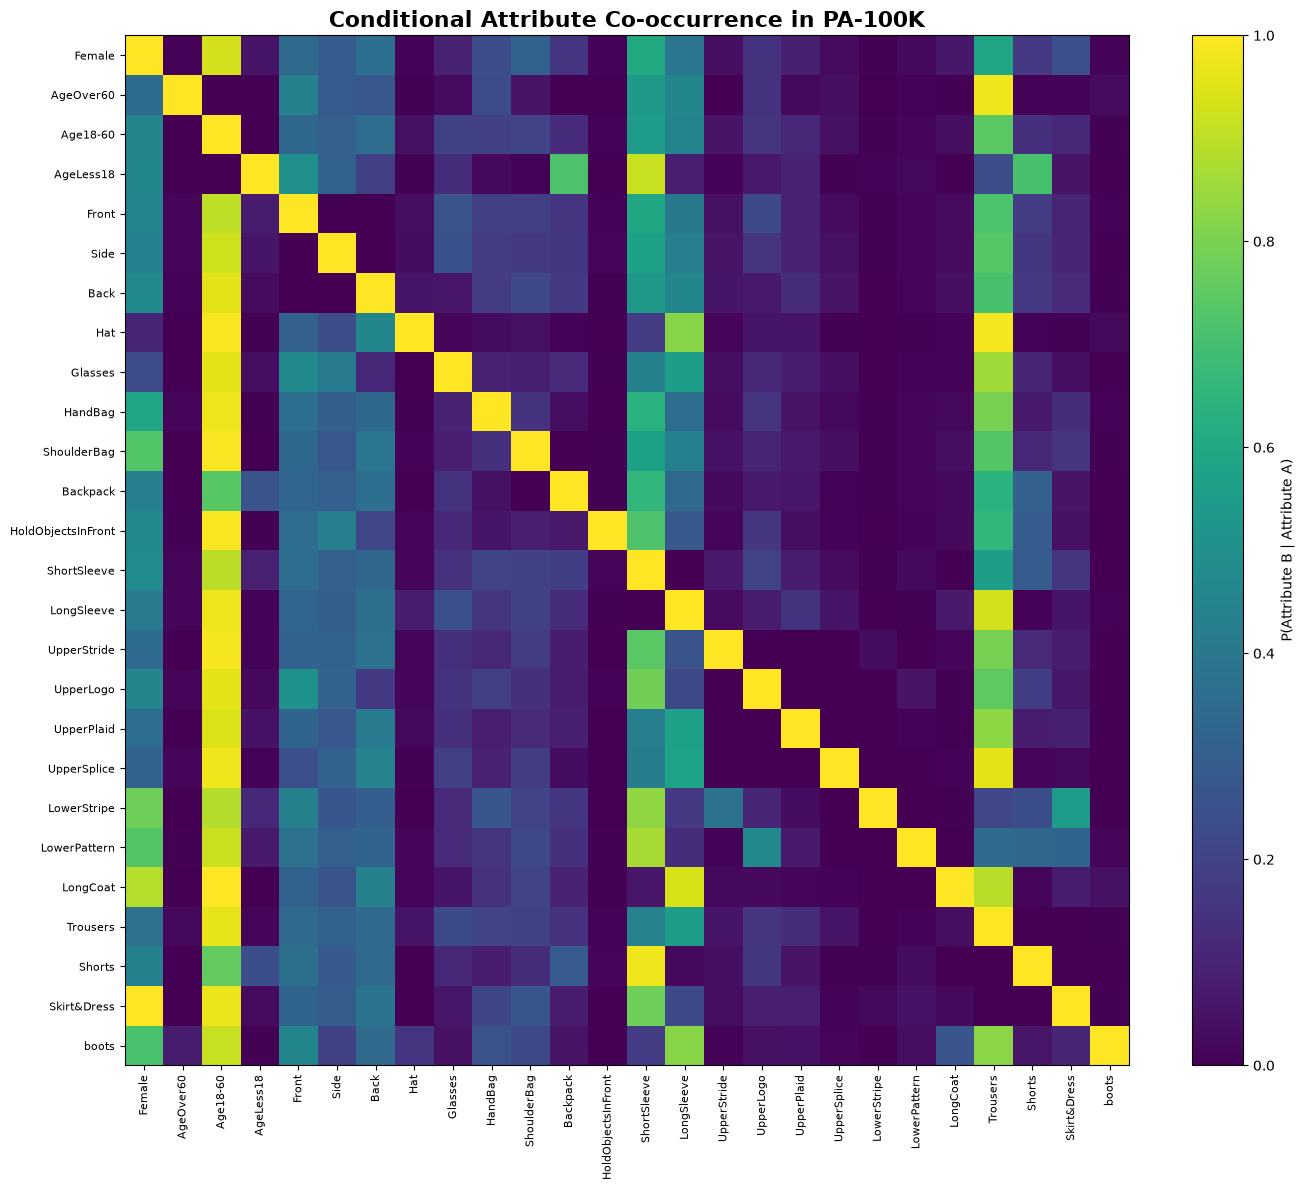

In [28]:
attribute_matrix = full_df[attribute_cols]

co = attribute_matrix.T @ attribute_matrix

attribute_counts = np.diag(co).astype(float)

normalized_co = (
    co.to_numpy()
    /
    np.maximum(attribute_counts[:, None], 1)
)

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    normalized_co,
    aspect="auto"
)

ax.set_xticks(range(len(attribute_cols)))
ax.set_yticks(range(len(attribute_cols)))

ax.set_xticklabels(
    attribute_cols,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    attribute_cols,
    fontsize=8
)

ax.set_title(
    "Conditional Attribute Co-occurrence in PA-100K",
    fontsize=16,
    fontweight="bold"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("P(Attribute B | Attribute A)")

plt.tight_layout()
plt.show()

## Pearson/phi correlation

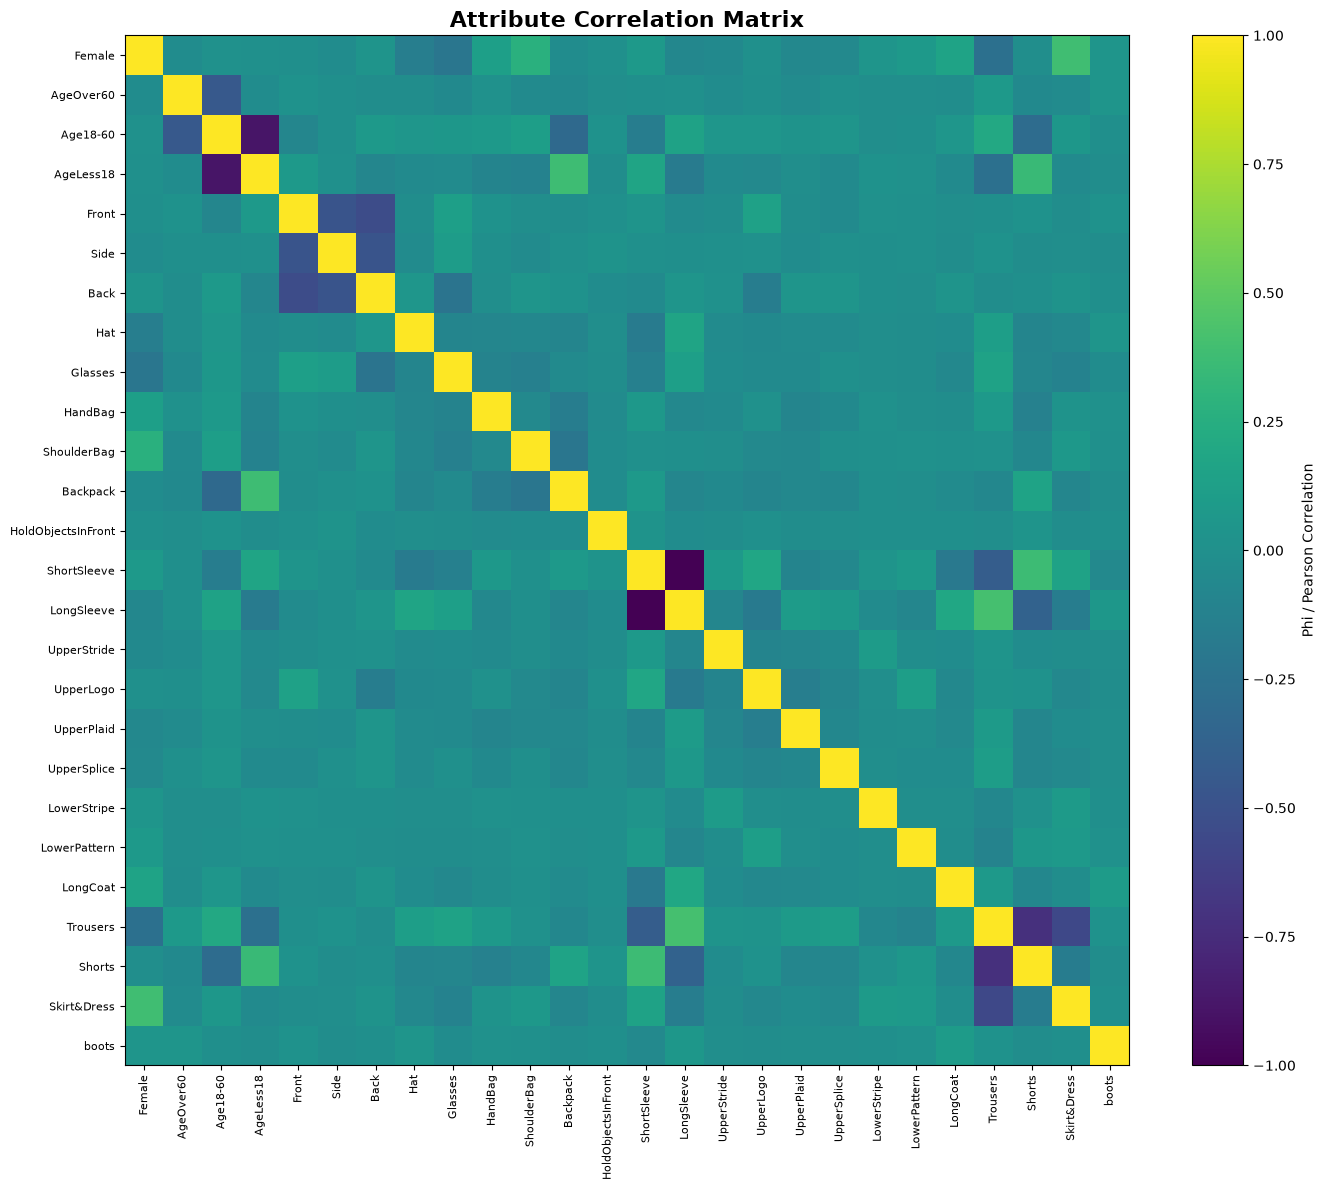

In [29]:
corr = full_df[attribute_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(attribute_cols)))
ax.set_yticks(range(len(attribute_cols)))

ax.set_xticklabels(
    attribute_cols,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    attribute_cols,
    fontsize=8
)

ax.set_title(
    "Attribute Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Phi / Pearson Correlation")

plt.tight_layout()
plt.show()

## Strongest attribute relationships

In [30]:
pairs = []

for i in range(len(attribute_cols)):
    for j in range(i + 1, len(attribute_cols)):

        a = attribute_cols[i]
        b = attribute_cols[j]

        pairs.append({
            "Attribute A": a,
            "Attribute B": b,
            "Correlation": corr.loc[a, b],
            "Absolute Correlation": abs(corr.loc[a, b])
        })

correlation_pairs = (
    pd.DataFrame(pairs)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

display(
    correlation_pairs.head(20).style.format({
        "Correlation": "{:.3f}",
        "Absolute Correlation": "{:.3f}"
    })
)

,Attribute A,Attribute B,Correlation,Absolute Correlation
247,ShortSleeve,LongSleeve,-1.000,1.000
49,Age18-60,AgeLess18,-0.884,0.884
319,Trousers,Shorts,-0.722,0.722
320,Trousers,Skirt&Dress,-0.567,0.567
95,Front,Back,-0.532,0.532
115,Side,Back,-0.484,0.484
94,Front,Side,-0.483,0.483
25,AgeOver60,Age18-60,-0.440,0.440
266,LongSleeve,Trousers,0.413,0.413
255,ShortSleeve,Trousers,-0.413,0.413


## Multi-label density

Average positive attributes/image : 5.64
Median positive attributes/image  : 6
Minimum                           : 4
Maximum                           : 10


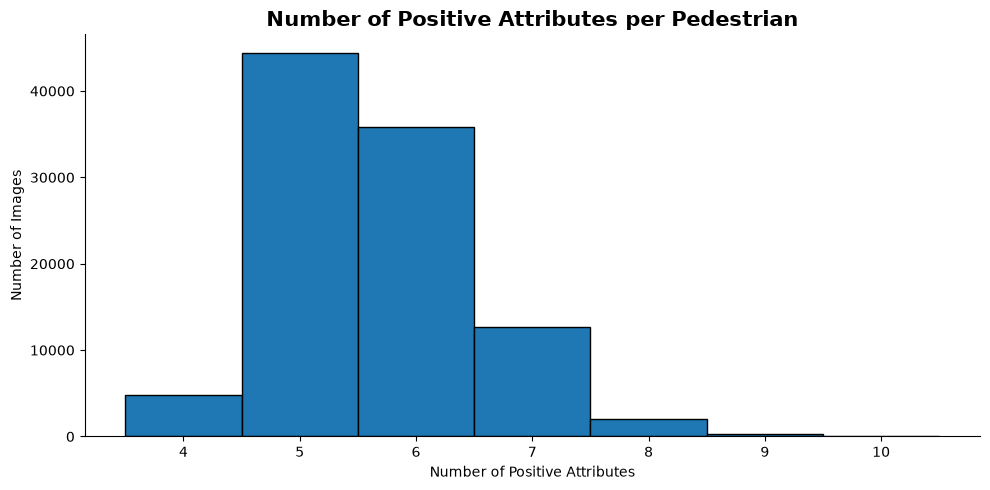

In [31]:
labels_per_image = full_df[attribute_cols].sum(axis=1)

print(f"Average positive attributes/image : {labels_per_image.mean():.2f}")
print(f"Median positive attributes/image  : {labels_per_image.median():.0f}")
print(f"Minimum                           : {labels_per_image.min()}")
print(f"Maximum                           : {labels_per_image.max()}")

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    labels_per_image,
    bins=np.arange(
        labels_per_image.min(),
        labels_per_image.max() + 2
    ) - 0.5,
    edgecolor="black"
)

ax.set_title(
    "Number of Positive Attributes per Pedestrian",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Number of Positive Attributes")
ax.set_ylabel("Number of Images")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Rare attribute positive counts

In [32]:
train_positive_counts = pd.DataFrame({
    "Attribute": attribute_cols,
    "Train Positive": [
        int(train_df[a].sum())
        for a in attribute_cols
    ],
    "Train Positive %": [
        train_df[a].mean() * 100
        for a in attribute_cols
    ]
}).sort_values("Train Positive")

display(
    train_positive_counts.style.format({
        "Train Positive": "{:,}",
        "Train Positive %": "{:.2f}%"
    })
)

,Attribute,Train Positive,Train Positive %
19,LowerStripe,404,0.51%
25,boots,495,0.62%
12,HoldObjectsInFront,771,0.96%
1,AgeOver60,"1,127",1.41%
20,LowerPattern,"1,421",1.78%
21,LongCoat,"2,256",2.82%
7,Hat,"3,516",4.40%
18,UpperSplice,"3,520",4.40%
15,UpperStride,"4,077",5.10%
3,AgeLess18,"4,152",5.19%


## Estimate what happens if we naively use 20K

In [33]:
TARGET_TRAIN_SIZE = 20_000

sampling_fraction = TARGET_TRAIN_SIZE / len(train_df)

subset_projection = train_positive_counts.copy()

subset_projection[
    "Expected Positives in Random 20K"
] = (
    subset_projection["Train Positive"]
    * sampling_fraction
).round().astype(int)

display(
    subset_projection.style.format({
        "Train Positive": "{:,}",
        "Train Positive %": "{:.2f}%",
        "Expected Positives in Random 20K": "{:,}"
    })
)

,Attribute,Train Positive,Train Positive %,Expected Positives in Random 20K
19,LowerStripe,404,0.51%,101
25,boots,495,0.62%,124
12,HoldObjectsInFront,771,0.96%,193
1,AgeOver60,"1,127",1.41%,282
20,LowerPattern,"1,421",1.78%,355
21,LongCoat,"2,256",2.82%,564
7,Hat,"3,516",4.40%,879
18,UpperSplice,"3,520",4.40%,880
15,UpperStride,"4,077",5.10%,"1,019"
3,AgeLess18,"4,152",5.19%,"1,038"


## Why Naive Random Subsampling Is Risky

The project has limited computational resources, so reducing the training set is desirable.

However, randomly reducing 80,000 training samples to approximately 20,000 also reduces the number of positive examples available for rare attributes.

For extremely rare labels, this may leave only tens or hundreds of positive training examples.

This increases the likelihood of:

- Minority-class overfitting
- Poor recall
- Majority-class bias
- Unstable validation performance
- Misleadingly high conventional accuracy

Therefore, the reduced dataset should be constructed using an **attribute-aware sampling strategy** rather than simple random sampling.

## Proposed initial attribute selection

In [34]:
selected_attributes = [
    # Balanced binary
    "Female",

    # Orientation
    "Front",
    "Side",
    "Back",

    # Sleeve
    "ShortSleeve",
    "LongSleeve",

    # Accessories
    "Hat",
    "Glasses",
    "HandBag",
    "ShoulderBag",
    "Backpack",

    # Upper clothing
    "UpperLogo",
    "UpperPlaid",

    # Lower clothing
    "Trousers",
    "Shorts",
    "Skirt&Dress"
]

selection_table = overall_stats[
    overall_stats["Attribute"].isin(selected_attributes)
][
    [
        "Attribute",
        "Positive",
        "Positive %",
        "Imbalance Ratio",
        "Frequency Group"
    ]
].sort_values("Positive %", ascending=False)

display(
    selection_table.style.format({
        "Positive": "{:,}",
        "Positive %": "{:.2f}%",
        "Imbalance Ratio": "{:.2f}"
    })
)

,Attribute,Positive,Positive %,Imbalance Ratio,Frequency Group
1,Trousers,"71,916",71.92%,2.56,Common
2,ShortSleeve,"56,913",56.91%,1.32,Common
3,Female,"45,336",45.34%,1.21,Common
4,LongSleeve,"43,087",43.09%,1.32,Common
5,Back,"34,785",34.78%,1.87,Common
6,Front,"34,707",34.71%,1.88,Common
7,Side,"30,508",30.51%,2.28,Common
8,ShoulderBag,"19,301",19.30%,4.18,Medium
9,Glasses,"18,662",18.66%,4.36,Medium
10,HandBag,"18,115",18.12%,4.52,Medium


## Excluded extreme attributes

In [35]:
excluded_initially = [
    "LowerStripe",
    "boots",
    "HoldObjectsInFront",
    "AgeOver60",
    "LowerPattern",
    "LongCoat"
]

excluded_table = overall_stats[
    overall_stats["Attribute"].isin(excluded_initially)
][
    [
        "Attribute",
        "Positive",
        "Positive %",
        "Imbalance Ratio",
        "Frequency Group"
    ]
].sort_values("Positive %")

display(
    excluded_table.style.format({
        "Positive": "{:,}",
        "Positive %": "{:.2f}%",
        "Imbalance Ratio": "{:.2f}"
    })
)

,Attribute,Positive,Positive %,Imbalance Ratio,Frequency Group
25,LowerStripe,450,0.45%,221.22,Extreme Rare
24,boots,595,0.60%,167.07,Extreme Rare
23,HoldObjectsInFront,958,0.96%,103.38,Extreme Rare
22,AgeOver60,"1,469",1.47%,67.07,Extreme Rare
21,LowerPattern,"1,639",1.64%,60.01,Extreme Rare
20,LongCoat,"3,365",3.36%,28.72,Rare


# Initial Attribute Selection

The initial model will **not attempt to predict all 26 PA-100K attributes**.

The selected attributes deliberately include a mixture of:

### Relatively balanced attributes

- Female
- Front / Side / Back
- ShortSleeve / LongSleeve

These provide stable baseline recognition tasks.

### Moderately imbalanced attributes

- Glasses
- HandBag
- ShoulderBag
- Backpack
- UpperLogo
- UpperPlaid
- Shorts
- Skirt&Dress

These allow evaluation of imbalance-aware training without having extremely limited positive data.

### Rare attribute

- Hat

Hat is intentionally retained despite its low prevalence.

This allows the project to test whether imbalance-aware approaches such as **Weighted BCE, Focal Loss, or Asymmetric Loss** improve minority-attribute recognition.

### Initially excluded attributes

Extremely rare attributes such as:

- LowerStripe
- boots
- HoldObjectsInFront
- LowerPattern

are not included in the first lightweight model because their extremely small positive sample counts would become particularly problematic after dataset reduction.

These attributes can later be investigated separately as an extreme long-tail experiment if computational resources and time permit.

# Model Design Suggested by the EDA

The analysis suggests using a shared visual backbone with task-specific prediction heads.

```text
                        Pedestrian Image
                               │
                               ▼
                     Pretrained Backbone
                  MobileNetV2 / EfficientNetB0
                               │
                               ▼
                        Shared Features
                               │
          ┌────────────┬───────┼──────────┬─────────────┐
          │            │       │          │             │
          ▼            ▼       ▼          ▼             ▼
       Gender        Pose    Sleeve      Lower       Accessory
        Head         Head     Head      Clothing        Head
          │            │       │          │             │
       Sigmoid      Softmax  Softmax    Softmax       Sigmoid
          │            │       │          │             │
       Female       Front    Short      Trousers       Hat
                    Side     Long       Shorts         Glasses
                    Back                Skirt/Dress     HandBag
                                                     ShoulderBag
                                                     Backpack
                                                     UpperLogo
                                                     UpperPlaid

# EDA Conclusions

The exploratory analysis leads to several important conclusions.

### 1. PA-100K is strongly imbalanced

Attribute prevalence varies dramatically across the dataset. Some labels are relatively balanced, whereas others occur in fewer than 1% of samples.

### 2. Overall accuracy is insufficient

Highly imbalanced attributes can produce deceptively high accuracy even when the minority class is poorly recognised.

The project will therefore emphasize **per-attribute recall, F1, mean accuracy and PR-AUC**.

### 3. Dataset reduction must be attribute-aware

Randomly reducing the 80,000-image training set could severely reduce the already limited number of minority-class examples.

A controlled sampling strategy will therefore be developed in the next stage.

### 4. Not all 26 labels are independent

Orientation, sleeve type, age and lower-body clothing exhibit categorical structure.

This motivates an attribute-aware multi-task architecture.

### 5. Extremely rare attributes will not dominate the first experiment

The first lightweight model will focus on a carefully selected mixture of balanced, moderately imbalanced and rare attributes.

### 6. Rare attributes will not be completely removed

At least one rare attribute, such as `Hat`, is deliberately retained to evaluate whether imbalance-aware learning improves minority recognition.